In [1]:
from dotenv import load_dotenv
load_dotenv()  # load API keys

from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState

C:\Users\gandh\AppData\Local\Temp\ipykernel_16968\2827973472.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [2]:
# load the PDF document
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()
print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [3]:
raw_docs[0].page_content

'Will EVs Dampen the Oil Price\n Shock?\nElectric Vehicles, Oil Demand Destruction, and the Future of Energy Price\n Volatility\n Version 1.0   |   April 2026\n Technical Reference Document'

In [4]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)

chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")

Split into 85 chunks


In [5]:
# initialize the embeddings and vector store
embeddings = GoogleGenerativeAIEmbeddings(model='gemini-embedding-001')

In [6]:
# in-memory only; re-running this cell re-embeds from scratch
vectorstore = Chroma(
    collection_name="rag_base",
    embedding_function=embeddings,
)

vectorstore.add_documents(documents=chunks)

retriever = vectorstore.as_retriever(search_kwargs={"k": 1}) 
print("Vector store ready")

Vector store ready


## Graph State

In [15]:
class AgenticRagState(MessagesState):

    query : str
    retrieved_docs : list[Document]
    context : str
    response : str

In [8]:
# initialize the LLM
llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

In [16]:
# retrieves relevant Docs from the vector store

def retrieve(state: AgenticRagState) -> dict:

    docs = retriever.invoke(state['query'])

    context = "\n\n".join(doc.page_content for doc in docs)

    return {"retriever_docs": docs, "context": context}

In [17]:
# generates a response using the retrieved context

def generate(state: AgenticRagState) -> dict:
    query = state["query"]
    context = state.get("context") or ""

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Answer the question using only the context below. in max to max 2 lines \n\nContext:\n{context}"),
        ("human", "{query}"),
    ])

    response = (prompt_template | llm).invoke({"context": context, "query": query})

    return {"response": response.content}

### Build Graph

In [19]:
graph_builder = StateGraph(AgenticRagState)

graph_builder.add_node("retrieve",retrieve)
graph_builder.add_node("generate",generate)

graph_builder.add_edge(START,"retrieve")
graph_builder.add_edge("retrieve","generate")
graph_builder.add_edge("generate",END)

graph = graph_builder.compile()

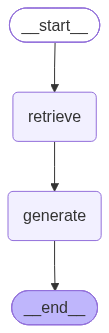

In [12]:
graph

In [20]:
test_query = "How will EVS impact oil demand in the next decade?"

result = graph.invoke({"query": test_query, "messages": []})

In [21]:
result['response']

'By 2030, a fleet of 300 million EVs could displace approximately 4.6 million barrels of oil per day. Between 2035-2040, this displacement could reach 10 to 15 million barrels per day, potentially causing absolute oil demand to decline.'

In [22]:
result['context']

"average, equivalent to approximately 1 barrel of oil per month per vehicle. A fleet of 300\nmillion EVs would therefore displace approximately 4.6 million barrels of oil per day by 2030\n— a meaningful but not transformative reduction against a global demand base of 100 to 105\nmillion barrels per day. In the 2035–2040 period, displacement could reach 10 to 15 million\nbarrels per day, sufficient to bring absolute oil demand into structural decline. The IEA's"